# Default Correlations and Credit Portfolio Risk

As usual, we'll start the notebook by loading all the data we may need.

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression
from scipy.stats import kendalltau
from scipy.stats import binom, norm
from scipy.optimize import brentq,minimize,fsolve
from scipy.integrate import quad
from scipy.stats import multivariate_normal,gamma
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.tsa.arima.model import ARIMA


In [139]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

Banks hold large portfolios of loans and similarly to asset management, correlations or more generally dependencies are the main drives of risk of the portfolio. 

Let $L_i$ be the random loss for a credit risky instrument $i$, where $i=1,....,n$ in a certain time period. The portfolio loss is the sum over the losses of all instruments($L = \sum_{i=1}^nL_i$). Let $F(L)$ be the cumulative distribution function of $L$. The risk measures then become:

$$E(L) = E\left(\sum_{i=1}^n L_i\right)$$

$$VaR_{\alpha}(L) = inf{F^{-1}(\alpha)}$$

where F^{-1}(\dot) is the generalized inverse of the CDF

$$EC_{\alpha} = VaR_{\alpha}(L) - E(L)$$

$$ES_{\alpha}(L) = E(L|L>VaR_{\alpha}(L))$$

Interessingly enough, the book brings that there's a paper by Gordy(2000) in which is showed that the most widely applied approeaches can be unified and if adequately parameterized yield similar results and that the risk of choosing the wrong model is not a big issue on a portfolio level.

## MODELING LOSS DISTRIBUTIONS WITH CORRELATED DEFAULTS

In order to show the issue with correlation, let the loss of instrument $i, i = 1, \dots, n$, be:

$$L_i = EAD_i \cdot LGD_i \cdot D_i$$

where $EAD_i$ and $LGD_i$ are the exposure at default and the loss given default, and $D_i$ is a default indicator variable. Let us for now assume that EAD and LGD are deterministic. The randomness of the loss is then driven by the default indicator, which is given by:

$$D_i = \begin{cases} 1 & \text{borrower } i \text{ defaults} \\ 0 & \text{otherwise} \end{cases}$$

Now consider a simple portfolio of two obligors with portfolio loss:

$$L = L_1 + L_2 = EAD_1 \cdot LGD_1 \cdot D_1 + EAD_2 \cdot LGD_2 \cdot D_2$$

Let $P(D_i = 1)$ be the probability of borrower $i$ defaulting $(i \in \{1, 2\})$ and let $P(D_1 = 1 \cap D_2 = 1)$ be the joint probability of both borrowers defaulting $(i \neq j)$. There are four potential scenarios for the default behavior of both borrowers (and therefore for the portfolio loss), as depicted in the following table.

| Borrower 1 | Borrower 2: No Default | Borrower 2: Default | Total |
| :--- | :--- | :--- | :--- |
| **No Default** | $P(D_1 = 0 \cap D_2 = 0)$ | $P(D_1 = 0 \cap D_2 = 1)$ | $P(D_1 = 0)$ |
| **Default** | $P(D_1 = 1 \cap D_2 = 0)$ | $P(D_1 = 1 \cap D_2 = 1)$ | $P(D_1 = 1)$ |
| **Total** | $P(D_2 = 0)$ | $P(D_2 = 1)$ | 1 |

The outcome combinations are: (1) neither borrower defaults, (2) Borrower 1 defaults, (3) Borrower 2 defaults, or (4) both borrowers default. The respective probabilities for these events are given in the table. The probabilities at the margins of the table are the marginal probabilities of default and nondefault for each borrower. 

In the special case of independence of the two borrowers, the probability that both borrowers default (i.e., their joint default probability $P(D_1 = 1 \cap D_2 = 1)$) equals the product of their marginal probabilities (which is per definition of independence). However, if the defaults are positively dependent (e.g., due to macroeconomic factors, which are the same for all borrowers in a given period), the joint default probability is higher than in the case of independence. As the joint default probability gives the probability for the highest possible loss of the portfolio (namely a total loss), we can see that, *ceteris paribus*, the extreme risk of the bank increases with default dependence. The default correlation can be computed as:

$$\rho^{D} = Corr(D_1, D_2) = \frac{E(D_1 \cdot D_2) - E(D_1) \cdot E(D_2)}{\sqrt{Var(D_1)Var(D_2)}} = \frac{P(D_1 = 1 \cap D_2 = 1) - P(D_1 = 1) \cdot P(D_2 = 1)}{\sqrt{P(D_1 = 1)(1 - P(D_1 = 1))P(D_2 = 1)(1 - P(D_2 = 1))}}$$

For two borrowers, it is hard to empirically quantify a value for the default correlation or the joint default probability in practice. For a higher number of borrowers this becomes burdensome, if not impossible. For two borrowers, there are four probabilities in the table. For $n$ borrowers, this would require $2^n$ probabilities, which is challenging for most credit portfolios. Therefore, a model is needed.

### Basic Model Framework

The Bernoulli default indicator variable can be characterized using some underlying metrict variable that renders $D_i=1$ if it crosses some threshold and $D_i=0$ otherwise, so we can re-write our definition of $D_i$ from above as follows:

$$D_i = \begin{cases} 1 & \text{if } R_i < c_i \\ 0 & \text{if} R_i \geq c_i \end{cases}$$


Where $c_i$ is the threshold value. The PD can then be expressed as $PD_i = P(D_i = 1) = P(R_i < c_i)$. If it's assumed that $R_i$ is a normalized asset return, then $PD_i = P(D_i = 1) = P(R_i < c_i) = \Phi(i), which is the approeach taken in the probit model$

Instead of defining $2^n$ correlations, we assume each borrower's asset value is driven by one common systemic factor (the economy) and one idiosyncratic factor (firm-specific), and so, the $R_i$ variable becomes:

$$R_i = \sqrt{\rho}X + \sqrt{1- \rho}\epsilon_i$$

where $X \sim N(0,1), \epsilon_i \sim N(0,1)$ i.i.d. You are probably familiar with this and can see that we are going to derive Vasicek. Under this extension, a stochastic, conditional PD (CPD), can be given that is conditioned on the systematic random factor X as:

$$CPD_i(X) = \Phi\left(\frac{c_i - \sqrt{\rho}X}{\sqrt{1-\rho}}\right)$$

### Analytical Solution

The CPD has expectation

$$E(CPD_i(X)) = \int_{-\infty}^{\infty} \Phi \left( \frac{c_i - \sqrt{\rho}x}{\sqrt{1 - \rho}} \right) \phi(x)dx$$
$$= PD_i$$

where $\phi(\cdot)$ is the standard normal probability density function (PDF), and variance

$$Var(CPD_i(X)) = E(CPD_i(X)^2) - [E(CPD_i(X))]^2$$
$$= \Phi(c_i, c_i, \rho) - PD_i^2$$

where $\Phi(c_i, c_i, \rho)$ is the bivariate normal CDF with correlation $\rho$ and standardized margins; for more details see [Gordy (2000)](https://www.sciepub.com/reference/239541). The density $g(p_i)$ of $P_i = CPD_i(X)$ is given by:

$$g(p_i) = \frac{\sqrt{1-\rho}}{\sqrt{\rho}} \cdot \frac{\phi \left( \frac{c_i - \Phi^{-1}(p_i)\sqrt{1-\rho}}{\sqrt{\rho}} \right)}{\phi(\Phi^{-1}(p_i))}$$

$$= \frac{\sqrt{1-\rho}}{\sqrt{\rho}} \cdot \exp \left( \frac{1}{2}(\Phi^{-1}(p_i))^2 - \frac{1}{2\rho}(c_i - \sqrt{1-\rho} \cdot \Phi^{-1}(p_i))^2 \right)$$

The CDF $G(p_i)$ and $\alpha$-quantile are:

$$G(p_i) = \Phi \left( \frac{\sqrt{1-\rho} \cdot \Phi^{-1}(p_i) - c_i}{\sqrt{\rho}} \right)$$

$$q_{\alpha} = \Phi \left( \frac{c_i + \sqrt{\rho}\Phi^{-1}(\alpha)}{\sqrt{1-\rho}} \right)$$

The joint probability of default for two obligors now becomes:

$$P(D_1 = 1 \cap D_2 = 1) = \int_{-\infty}^{\infty} \Phi \left( \frac{c_1 - \sqrt{\rho}x}{\sqrt{1-\rho}} \right) \Phi \left( \frac{c_2 - \sqrt{\rho}x}{\sqrt{1-\rho}} \right) \phi(x)dx$$
$$= \Phi(c_1, c_2, \rho)$$

where $\phi(x)$ is the standard normal PDF. The default correlation is:

$$\rho^D = Corr(D_1, D_2) = \frac{\Phi(c_1, c_2, \rho) - PD_1 PD_2}{\sqrt{PD_1(1-PD_1)}\sqrt{PD_2(1-PD_2)}}$$

It can be shown that if a portfolio has homogeneous parameters (i.e., PD and correlation) and infinitely many borrowers, the density $g(p_i)$ represents its default rate distribution. This model is sometimes called the asymptotic single risk factor (ASRF) model or Vasicek model. The risk contribution of any loan to the risk of a portfolio can be computed by considering the properties of the loan only and does not require considering the portfolio in which the loan is held. Thus, risk contributions are portfolio invariant. Hence, the risk contribution of a loan in terms of value at risk is directly given by $q_{\alpha}$. So, if the correlation and the confidence level $\alpha$ are given, the risk contribution and hence capital can be computed as a function of the probability of default (PD). This is exactly the approach followed in the Basel IRBA formula, which uses $q_{\alpha}$ as the key constituent. There the capital requirements are computed via

$$C = LGD \cdot \left[ \Phi \left( \frac{\Phi^{-1}(PD) + \sqrt{\rho}\Phi^{-1}(0.999)}{\sqrt{1-\rho}} \right) - PD \right] \cdot \frac{1 + (M - 2.5)b}{1 - 1.5b}$$

where the last factor is a maturity adjustment with $b = (0.11852 - 0.05478 \cdot \ln(PD))^2$ to account for the fact that long-term credits are more risky than short-term credits and maturity effects are more pronounced for obligors with low PDs. In the capital requirement formula for corporates, sovereigns, and banks, the correlation is a function of the PD as follows:

$$\rho = \rho(PD) = 0.12 \frac{1 - \exp^{-50 \cdot PD}}{1 - \exp^{-50}} + 0.24 \left( 1 - \frac{1 - \exp^{-50 \cdot PD}}{1 - \exp^{-50}} \right)$$

The first expression in square brackets of the capital formula is the 99.9th percentile of the CPD from which the expected loss is subtracted. The result is then multiplied by the loss given default (LGD) and the maturity adjustment. The correlation is assumed to be a decreasing function of the PD with lower bound of 12 percent for high PDs and upper bound of 24 percent for low PDs. The decreasing form of the correlation leads to a flattening of the capital curve for higher PDs. Risk-weighted assets (RWA) are then computed as:

$$RWA = C \cdot 12.5 \cdot EAD$$

The maturity $M$ represents the nominal or effective maturity and is between 1 and 5 years. For exposures to large financial sector entities, $\rho$ is multiplied by 1.25. For retail exposures, there is no maturity adjustment. For residential mortgages, the asset correlation has been set to 15 percent, for qualifying revolving exposures to 4 percent. For other retail exposures the asset correlation is a decreasing function of the PD with lower bound of 3 percent for high PDs and upper bound of 16 percent for low PDs:

$$\rho = \rho(PD) = 0.03 \frac{1 - \exp^{-35 \cdot PD}}{1 - \exp^{-35}} + 0.16 \left( 1 - \frac{1 - \exp^{-35 \cdot PD}}{1 - \exp^{-35}} \right)$$

In the United States, the latter has been set to: $\rho = 0.03 + 0.13\exp^{-35 \cdot PD}$.

It is important to emphasize again that the risk weight functions cover unexpected loss, since expected loss should be covered by provisions; as we are already expecting to lose that amount we provision to that loss as to not impact results much when they, in fact, occur. Also note that the risk-weighted assets are not explicitly calculated. They can, however, be backed out using the relationship that regulatory capital equals 8 percent of the risk-weighted assets. This implies that the risk-weighted assets are equal to 12.50 times the regulatory capital. Also, as a result of various quantitative impact studies run by the Basel group, an additional scaling factor of 1.06 is applied to the risk-weighted assets.

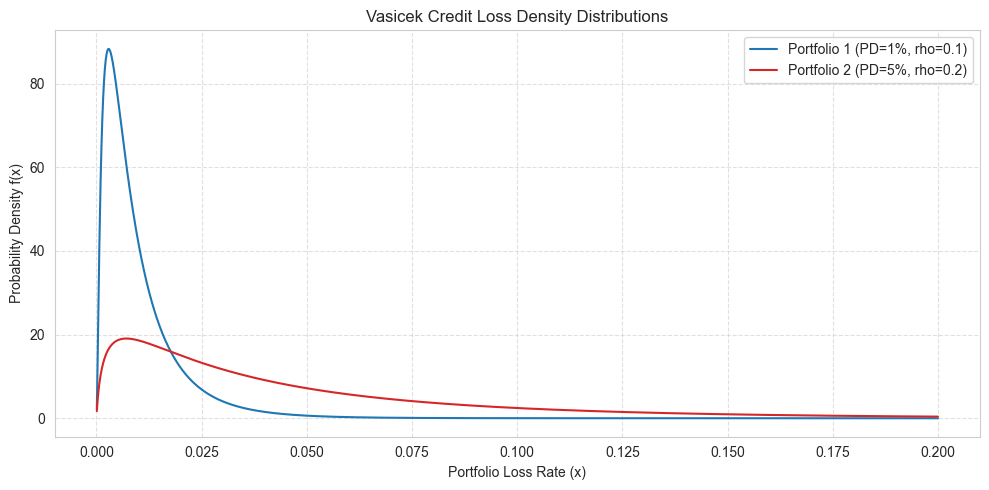

In [140]:
pd1, rho1 = 0.01, 0.1
pd2, rho2 = 0.05, 0.2

loss_rates = np.arange(0.0001, 0.2001, 0.0001)

def vasicek_pdf(x, pd_val, rho):
    """Vasicek Probability Density Function."""
    term1 = np.sqrt((1 - rho) / rho)
    probit_x = norm.ppf(x)
    probit_pd = norm.ppf(pd_val)
    
    exponent = 0.5 * (probit_x**2) - (0.5 / rho) * (probit_pd - np.sqrt(1 - rho) * probit_x)**2
    return term1 * np.exp(exponent)

density_1 = vasicek_pdf(loss_rates, pd1, rho1)
density_2 = vasicek_pdf(loss_rates, pd2, rho2)

plt.figure(figsize=(10, 5))
plt.plot(loss_rates, density_1, label='Portfolio 1 (PD=1%, rho=0.1)', color='tab:blue')
plt.plot(loss_rates, density_2, label='Portfolio 2 (PD=5%, rho=0.2)', color='tab:red')

plt.title('Vasicek Credit Loss Density Distributions')
plt.xlabel('Portfolio Loss Rate (x)')
plt.ylabel('Probability Density f(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save image and data
plt.savefig('vasicek_plot.png')
pd.DataFrame({'loss': loss_rates, 'PD_1_density': density_1, 'PD_5_density': density_2}).to_csv('analytic_data.csv', index=False)

### Numerical Solution

In a portfolio with a finite number of borrowers, idiosyncratic risk is not canceled out, which means it must be taken into account when the loss distribution is computed. We condition again on the systematic factor and assume homogeneous borrowers (i.e., $PD_i = PD, \forall i$). Note that the remaining stochastic variables $\epsilon_i$ are independent. Assume further that defaults are independent for a given realization of the systematic factor $X = x$. The number of defaults $D = \sum_{i=1}^{n} D_i$ is conditionally binomially distributed:

$$P(D = d|x) = \binom{n}{d} CPD(x)^d(1 - CPD(x))^{n-d}, d = 0, \dots, n$$

The final unconditional distribution is then found by mixing (integrating) over the distribution of the random factor $X$ as

$$P(D = d) = \int_{-\infty}^{\infty} \binom{n}{d} CPD(x)^d(1 - CPD(x))^{n-d} \phi(x)dx, d = 0, \dots, n$$



That is, this integral represents the unconditional probability of observing exactly d defaults in a finite portfolio. Because we do not know the exact state of the economy (the systematic factor $x$), we must "average" the conditional probabilities across all possible economic outcomes. That is what it does by using $-\infty, \infty$ bounds, accounting for every possible realization of the systematic risk factor x; $\binom{n}{d}$ accounts for all different combinations that $d$ borrowers can default out of a total of $n$ borrowers in the portfolio, because we don't know which borrowers defaulted, only the total count; $CPD(x)^d(1 - CPD(x))^{n-d}$ represents the idiosyncratic risk, while $\phi(x)$ acts as a weight based on the economic state (systematic factor $x$).

In [141]:
rho = 0.2    # Asset correlation (rho)
N = 100      # Number of borrowers (n)
p = 0.05     # Probability of Default (p)

results = []

def integrand(x, k, n, p, rho):
    """
    Calculates the CPD and multiplies by the standard normal PDF.
    Equivalent to the 'START fun(x)' module in the SAS code.
    """
    term1 = 1 / np.sqrt(1 - rho)
    term2 = norm.ppf(p) - np.sqrt(rho) * x
    cpd = norm.cdf(term1 * term2)
    
    prob_k = binom.pmf(k, n, cpd)
    
    return prob_k * norm.pdf(x)

k = 0
cumulative_prob = 0

while cumulative_prob < 0.9999 and k <= N:
    prob, error = quad(integrand, -np.inf, np.inf, args=(k, N, p, rho), epsabs=1.34e-15)
    
    cumulative_prob += prob
    default_rate = k / N
    
    results.append({
        'N': N,
        'rho': rho,
        'p': p,
        'quantile': k,
        'default_rate': default_rate,
        'prob': prob
    })
    
    k += 1
df_numeric = pd.DataFrame(results)
print(df_numeric.head())

     N  rho     p  quantile  default_rate      prob
0  100  0.2  0.05         0          0.00  0.153011
1  100  0.2  0.05         1          0.01  0.148625
2  100  0.2  0.05         2          0.02  0.124860
3  100  0.2  0.05         3          0.03  0.101726
4  100  0.2  0.05         4          0.04  0.082393


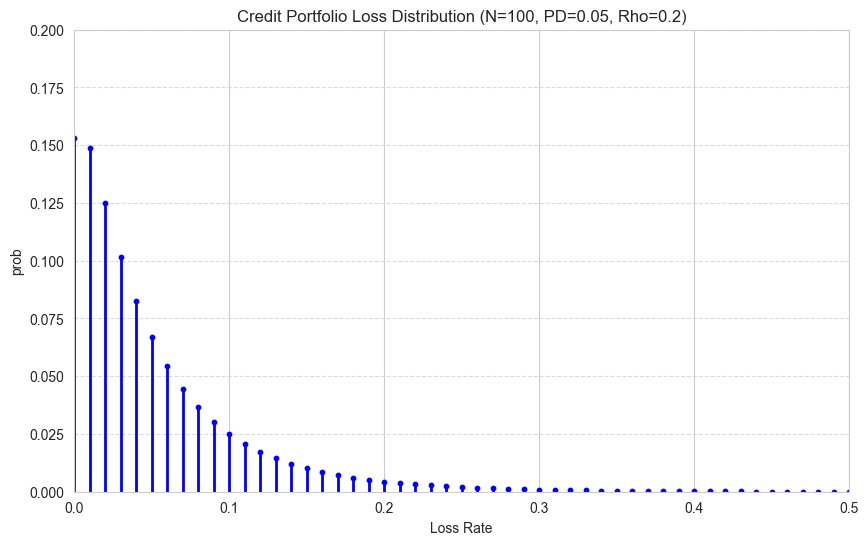

In [142]:
plt.figure(figsize=(10, 6))
plt.vlines(df_numeric['default_rate'], ymin=0, ymax=df_numeric['prob'], colors='blue', lw=2)
plt.scatter(df_numeric['default_rate'], df_numeric['prob'], color='blue', s=10)

plt.title(f'Credit Portfolio Loss Distribution (N={N}, PD={p}, Rho={rho})')
plt.xlabel('Loss Rate')
plt.ylabel('prob')
plt.xlim(0, 0.5)  # Range specified in SAS AXIS1
plt.ylim(0, 0.2)  # Range specified in SAS AXIS2
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Monte Carlo Simulation

The most flexible way of deriving loss distributions is via Monte Carlo simulations.

In [143]:
n_sim = 10000  # Number of simulations
n = 10000       # Number of borrowers
p = 0.05        # Homogeneous PD
w_2 = 0.2       # Asset correlation (rho)

w = np.sqrt(w_2)           # SQRT(w_2)
ksi = np.sqrt(1 - w_2)     # SQRT(1-w_2)
from scipy.stats import norm
threshold = norm.ppf(p)    # PROBIT(PD)

z = np.random.standard_normal((n_sim, 1)) # RANNOR(x1)
eps = np.random.standard_normal((n_sim, n)) # RANNOR(x2)
lnV = w * z + ksi * eps
defaults_matrix = lnV < threshold
d_counts = np.sum(defaults_matrix, axis=1) # defaults[+]
loss_rates = d_counts / n                  # defaults[+]/N
sim_results = pd.DataFrame({
    'sim': np.arange(1, n_sim + 1),
    'N': n,
    'D': d_counts,
    'Loss': loss_rates
})

print(sim_results.head())

   sim      N     D    Loss
0    1  10000   665  0.0665
1    2  10000    64  0.0064
2    3  10000   680  0.0680
3    4  10000   153  0.0153
4    5  10000  2082  0.2082


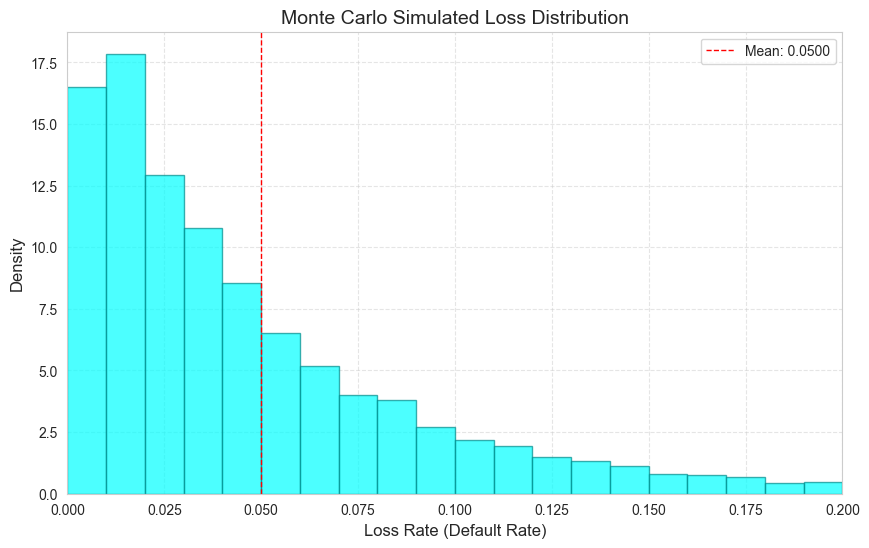

In [144]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
bins = np.arange(0, 0.21, 0.01)

n_count, bins, patches = plt.hist(
    sim_results['Loss'], 
    bins=bins, 
    color='cyan', 
    edgecolor='darkcyan', 
    alpha=0.7,
    density=True
)
plt.title('Monte Carlo Simulated Loss Distribution', fontsize=14)
plt.xlabel('Loss Rate (Default Rate)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(sim_results['Loss'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {sim_results["Loss"].mean():.4f}')
plt.legend()
plt.show()

### Estimating Correlations

For parameter estimation, we consider some of the most popular estimation techniques such as the method of moments (MM), maximum likelihood (ML), and probit-linear regressions.


#### Method of Moments

The method of moments technique replaces population moments by their empirical counterparts. It requires a time series of default in a homogenous segment where $d_t = \sum^{N_1}_{i=1}d_{it}(i=1,....,n_t;t=1,....T)$ is the number of defaults and $n_t$ is the number of borrowers observed in year $t$. The estimator for the default probability is simply given by the average yearly default rate as:

$$\widehat{PD} = \frac{1}{T}\sum_{t=1}^T\frac{d_t}{n_t}$$

and the variance of the default rate is estimated by the historical mean squared error (MSE) as:

$$\widehat{\sigma}^2 = \frac{1}{T}\sum_{t=1}^T(\frac{d_t}{n_t}-{\widehat{PD}}^2)$$

an estimafor for the variance of the CPD is given by

$$\widehat{\operatorname{Var}}(CPD) = \frac{\sigma^2 - \frac{1}{T} \sum_{t=1}^T \frac{\widehat{PD}_t(1-\widehat{PD}_t)}{n_t}}{1 - \frac{1}{T} \sum_{t=1}^T \frac{1}{n_t}}$$

Finnaly, the estimator $\hat{\rho}$ for the asset correlation is obtained a numerical solution for

$$\widehat{Var}(CPD) = \Phi_2(\Phi^{-1}(\widehat{PD}), \Phi^{-1}(\widehat{PD}), \hat{\rho}) - \widehat{PD}^2$$

where $\Phi_2(.,.,\widehat{rho})$ denotes the CDF of the bivariate standardized normal distribution with correlation $\widehat{rho}$.




In [145]:
# First code block
means = mortgage.groupby('time').agg(
    default_time=('default_time', 'mean'),
    gdp_time=('gdp_time', 'mean'),
    _FREQ_=('default_time', 'count')
).reset_index()

tmp2 = means.copy()
tmp2['n_default'] = tmp2['default_time'] * tmp2['_FREQ_']
tmp2['default_time_1'] = tmp2['default_time'].shift(1)
tmp2['Probit_dr'] = norm.ppf(tmp2['default_time'])

# Second code block
default_rate = tmp2['default_time'].values
lambda_hat = np.mean(default_rate)
lambda_hat2 = lambda_hat**2
n_t = tmp2['_FREQ_'].values
n_inverse = 1 / n_t
threshold = norm.ppf(lambda_hat)
mse = np.mean((default_rate - lambda_hat)**2)

# Variance of the CPD (Var_lambda_hat)
# Formula: (MSE - avg(1/n_t) * lambda_hat * (1-lambda_hat)) / (1 - avg(1/n_t))
avg_n_inv = np.mean(n_inverse)
var_lambda_hat = (mse - avg_n_inv * lambda_hat * (1 - lambda_hat)) / (1 - avg_n_inv)

print(f"Lambda Hat: {lambda_hat:.6f}")
print(f"MSE: {mse:.6f}")
print(f"Var Lambda Hat: {var_lambda_hat:.6f}")


# Third code block
def objective(x, threshold, lambda_hat2, var_val):   
    rho = x[0]
    # Covariance matrix for bivariate normal with correlation rho
    cov = [[1, rho], [rho, 1]]
    prob_bivariate = multivariate_normal.cdf([threshold, threshold], mean=[0, 0], cov=cov)
    
    f = np.abs(prob_bivariate - lambda_hat2 - var_val)
    return f

x0 = [0.99] # Initial guess
bounds = [(0.0000001, 0.9999999)]

res = minimize(
    objective, 
    x0, 
    args=(threshold, lambda_hat2, var_lambda_hat),
    method='L-BFGS-B', # Newton-Raphson equivalent with bounds
    bounds=bounds,
    options={'disp': True}
)

print("\n" + "="*30)
print("OPTIMIZATION RESULTS")
print("="*30)
print(f"Parameter X1 (Asset Correlation): {res.x[0]:.6f}")
print(f"Value of Objective Function:    {res.fun:.11e}")
print(f"Number of Iterations:           {res.nit}")
print(f"Function Calls:                 {res.nfev}")
print(f"Success:                        {res.success}")

Lambda Hat: 0.021156
MSE: 0.000137
Var Lambda Hat: 0.000129

OPTIMIZATION RESULTS
Parameter X1 (Asset Correlation): 0.045432
Value of Objective Function:    8.99899249627e-12
Number of Iterations:           8
Function Calls:                 66
Success:                        True


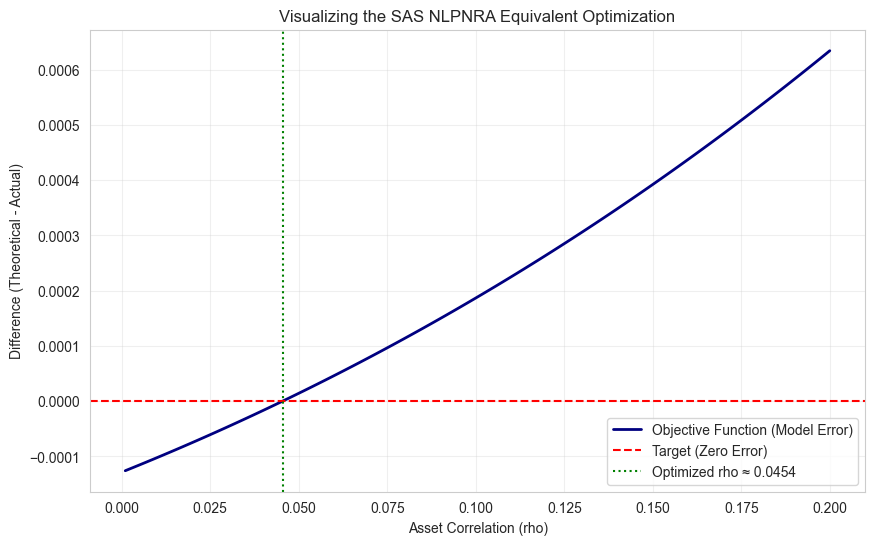

In [146]:
rho_range = np.linspace(0.001, 0.2, 100)
f_values = []

for r in rho_range:
    # Theoretical bivariate probability
    cov = [[1, r], [r, 1]]
    prob_bivariate = multivariate_normal.cdf([threshold, threshold], mean=[0, 0], cov=cov)
    # The "f" from your SAS code
    f_values.append(prob_bivariate - lambda_hat2 - var_lambda_hat)

plt.figure(figsize=(10, 6))
plt.plot(rho_range, f_values, label='Objective Function (Model Error)', color='navy', lw=2)
plt.axhline(0, color='red', linestyle='--', label='Target (Zero Error)')
plt.axvline(res.x[0], color='green', linestyle=':', label=f'Optimized rho ≈ {res.x[0]:.4f}')

plt.title('Visualizing the SAS NLPNRA Equivalent Optimization')
plt.xlabel('Asset Correlation (rho)')
plt.ylabel('Difference (Theoretical - Actual)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Let's also take a look at our data. If the bars (observed default rate) were all the same height, that is, if the observed default rate was constant, correlation would be 0, and the higher the bars move together, the higher the correlation estimation.

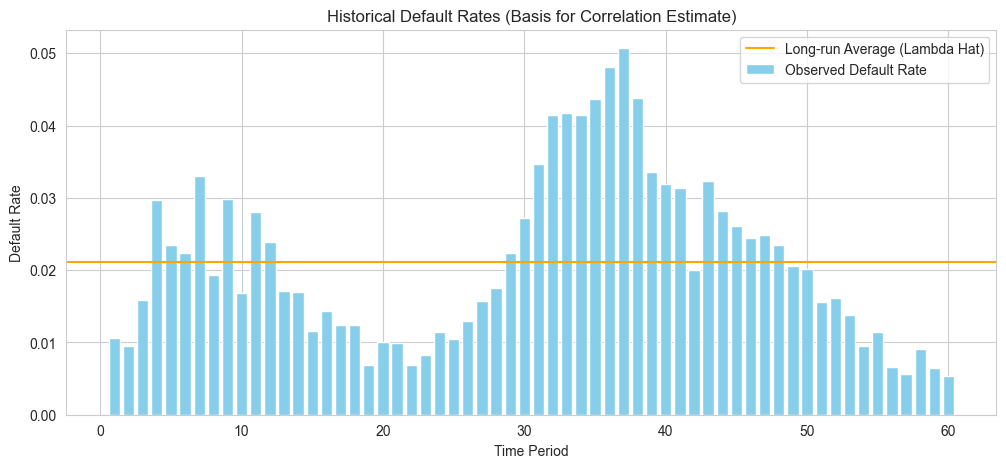

In [147]:
plt.figure(figsize=(12, 5))
plt.bar(tmp2['time'], tmp2['default_time'], color='skyblue', label='Observed Default Rate')
plt.axhline(lambda_hat, color='orange', linestyle='-', label='Long-run Average (Lambda Hat)')
plt.title('Historical Default Rates (Basis for Correlation Estimate)')
plt.xlabel('Time Period')
plt.ylabel('Default Rate')
plt.legend()
plt.show()

We could also do something like a linear regression to see how much of the default rate is explained by GDP, as when we add GDP to calculate the correlation we are trying to decompose the correlation into systematic (the part explained by the GDP) and idiosyncratic risk.

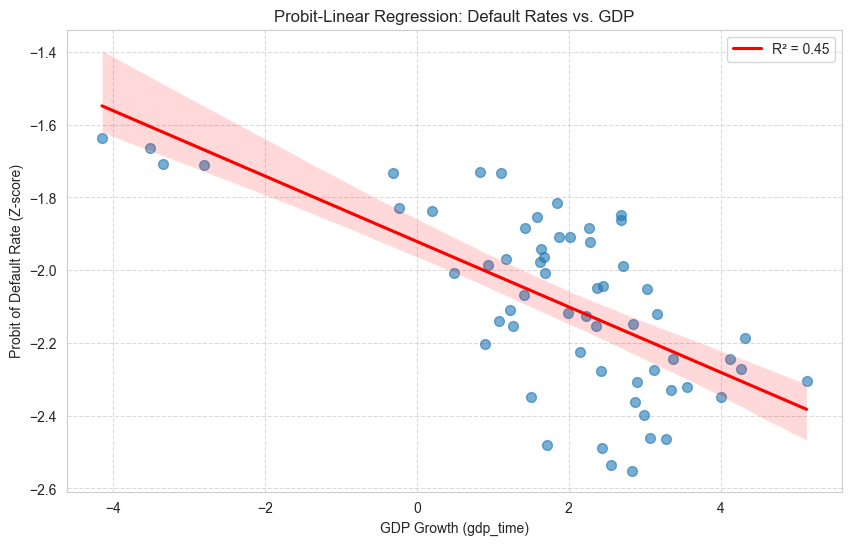

In [148]:
X = tmp2['gdp_time'].values.reshape(-1, 1)
y = tmp2['Probit_dr'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
sns.regplot(x='gdp_time', y='Probit_dr', data=tmp2, 
            scatter_kws={'s': 50, 'alpha': 0.6}, 
            line_kws={'color': 'red', 'label': f'R² = {model.score(X, y):.2f}'})

plt.title('Probit-Linear Regression: Default Rates vs. GDP')
plt.xlabel('GDP Growth (gdp_time)')
plt.ylabel('Probit of Default Rate (Z-score)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Maximum-Likelihood ASRF

Another widely used e3stimation technique is the maximum likelihood method. A special simple case is obtained under the assumption that the model has exactly one systematic risk factor and is homogeneous and asymptotic (ASRF). Under these assumptions, the CPD bnecomes the default rate of the asymptotic portolio, which stochastically depends on only the systematic random factor (as per the model assumption) and has two parameters: the PD and the correlation, which are given by:

$$\widehat{PD} = \Phi(\frac{\hat{c}}{\sqrt{1 + \widehat{Var}(\hat{c}_t)}})$$

and 

$$\widehat{\rho}=\frac{\widehat{Var}(\hat{c}_t)}{1+\widehat{Var}(\hat{c}_t)}$$

where $\hat{c} = \frac{1}{T}\sum_{t=1}^T\hat{c}_t^2-\hat{c}^2$, and $\hat{c}_t = \Phi^{-1}(\frac{d_t}{n_t})$

In [149]:
default_rates = tmp2.iloc[:, 1].values
c_t = norm.ppf(default_rates)
c_bar = np.mean(c_t)
var_c = np.var(c_t) 
pd_ml = norm.cdf(c_bar / np.sqrt(1 + var_c))
rho_ml = var_c / (1 + var_c)
print(f"Average Probit (c_bar):      {c_bar:.6f}")
print(f"Variance of Probits (Var_c): {var_c:.6f}")
print(f"Asset Correlation (rho_ML):  {rho_ml:.6f}")
print(f"Probability of Default (ML): {pd_ml:.6f}")

Average Probit (c_bar):      -2.086967
Variance of Probits (Var_c): 0.057137
Asset Correlation (rho_ML):  0.054049
Probability of Default (ML): 0.021189


### Probit-Linear Regression

#### Probit-Linear Regression without Covariates

The ASRF model can also be estimated in a simple way using a probit-linear regression model. In the ASRF model, it holds that the default rate $d_r = \frac{d_t}{n_t}$ in time $t$ equals the CPD.

As we have Vasicek given by

$$dt_t = \Phi(\frac{\Phi^{-1}(PD)-\sqrt{\rho}X_t}{\sqrt{1 - \rho}})$$

If we apply the probit transformation (applying $\Phi^{-1}$ to both sides), with $c = \Phi^{-1}(PD)$ we get:,

$$\Phi^{-1}(dr_t) = \frac{c-\sqrt{\rho}X}{\sqrt(1-\rho)} = \frac{c}{\sqrt{1-\rho}} - \frac{\sqrt{\rho}}{\sqrt{1-\rho}}X$$

which resumes to:

$$\Phi^{-1}(dr_t) = \alpha + \sigma \epsilon$$

Where $\Phi^{-1}(dr_t)$ represents the probit of the yearly default rate; $\alpha$ represents the threshold adjusted for correlation; and $\sigma \epsilon$ represents the volatility in defaults caused by the systematic risk factor

In [150]:
y = tmp2['Probit_dr']
X = sm.add_constant(pd.Series([1] * len(y), index=y.index))
X.columns = ['a'] # Renaming to match your SAS parameter 'a'
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())
a_estimate = results.params['a']
print(f"\nEstimate for Intercept (a): {a_estimate:.6f}")

                            OLS Regression Results                            
Dep. Variable:              Probit_dr   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 14 Mar 2026   Prob (F-statistic):                nan
Time:                        13:27:43   Log-Likelihood:                0.73277
No. Observations:                  60   AIC:                            0.5345
Df Residuals:                      59   BIC:                             2.629
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
a             -2.0870      0.031    -67.063      0.0

In [151]:
exhibit_summary = pd.DataFrame({
    'Parameter': ['a'],
    'Estimate': [results.params['a']],
    'Std Error': [results.bse['a']],
    't-Value': [results.tvalues['a']],
    'P-Value': [results.pvalues['a']]
})
print(exhibit_summary)

a = results.params['a']
var_c = results.mse_resid
rho_estimate = var_c / (1 + var_c)
pd_estimate = norm.cdf(a / np.sqrt(1 + var_c))
print(f"Asset Correlation (rho): {rho_estimate:.6f}")
print(f"Long-run PD:             {pd_estimate:.6f}")

  Parameter  Estimate  Std Error    t-Value       P-Value
0         a -2.086967    0.03112 -67.062967  2.128549e-57
Asset Correlation (rho): 0.054915
Long-run PD:             0.021236


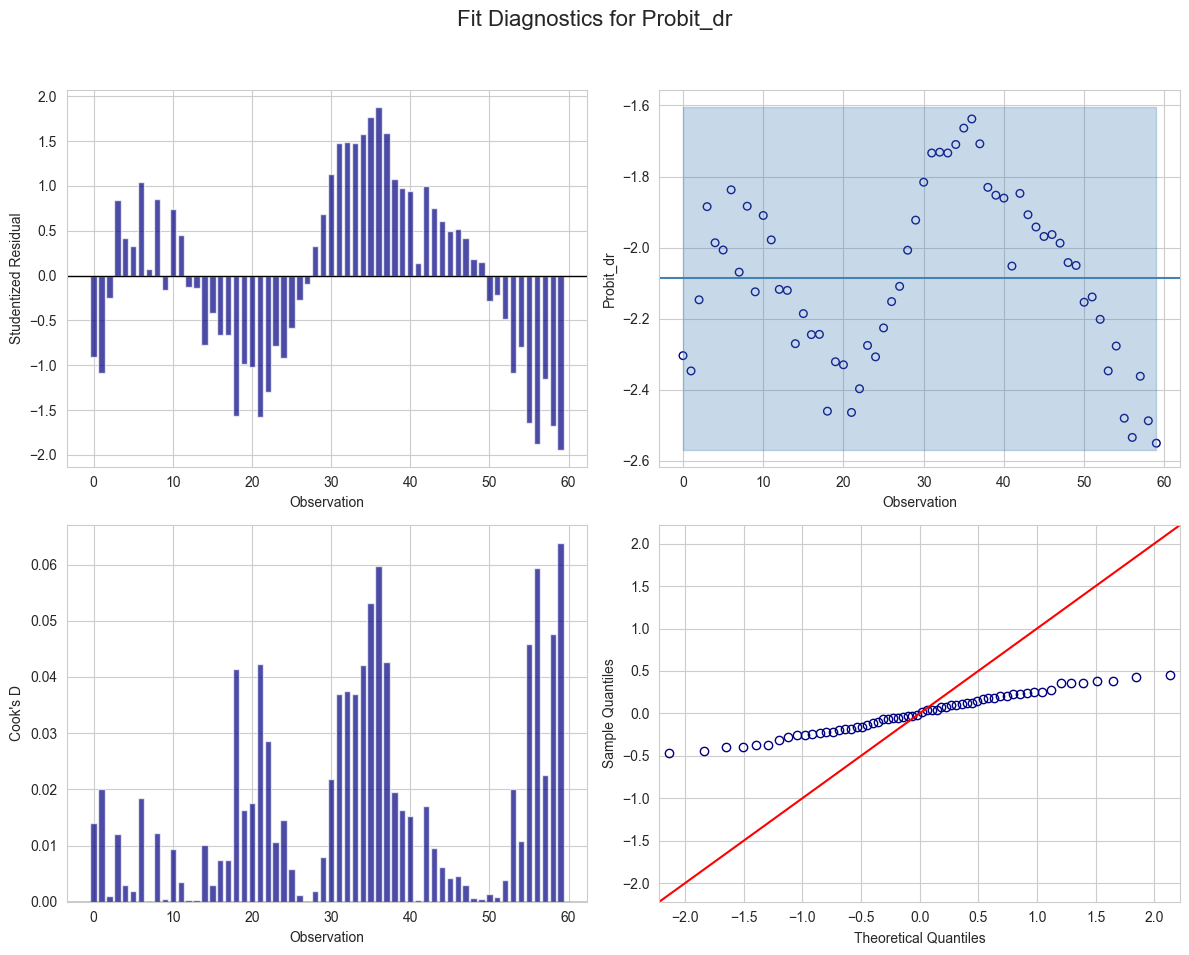

Observations: 60  MSE: 0.058105  Model DF: 0


In [152]:
influence = OLSInfluence(results)
studentized_residuals = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
observations = np.arange(len(y))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Fit Diagnostics for Probit_dr', fontsize=16)

# --- Top Left: Studentized Residuals (Bar Plot) ---
axes[0, 0].bar(observations, studentized_residuals, color='navy', alpha=0.7)
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_ylabel('Studentized Residual')
axes[0, 0].set_xlabel('Observation')

# --- Top Right: Predicted vs. Actual (Probit_dr) ---
axes[0, 1].scatter(observations, y, facecolors='none', edgecolors='navy', s=30)
axes[0, 1].axhline(results.params['a'], color='steelblue', label='Predicted')
axes[0, 1].fill_between(observations, results.params['a'] - 2*np.sqrt(results.mse_resid), 
                         results.params['a'] + 2*np.sqrt(results.mse_resid), color='steelblue', alpha=0.3)
axes[0, 1].set_ylabel('Probit_dr')
axes[0, 1].set_xlabel('Observation')

# --- Bottom Left: Cook's D (Bar Plot) ---
axes[1, 0].bar(observations, cooks_d, color='navy', alpha=0.7)
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_ylabel("Cook's D")
axes[1, 0].set_xlabel('Observation')

# --- Bottom Right: Q-Q Plot (Normal Probability Plot) ---
sm.qqplot(results.resid, line='45', ax=axes[1, 1], markerfacecolor='none', markeredgecolor='navy')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Observations: {len(y)}  MSE: {results.mse_resid:.6f}  Model DF: {int(results.df_model)}")

#### Probit-Linear Regression with Covariates

An important extension of the probit-linear regression model and an advantage of the analytical solutions is that covariates, particularly autoregressive (AR) effects and/or macroeconomic covariates, can be included. As an example we include the realized one-year lagged default rate in the regression model.

In [153]:
regression_data = tmp2.dropna(subset=['default_time_1', 'Probit_dr']).copy()
regression_data['probit_lagged'] = norm.ppf(regression_data['default_time_1'])
y = regression_data['Probit_dr']
X = sm.add_constant(regression_data[['probit_lagged']])
X.columns = ['a', 'probit_lagged']
model_with_cov = sm.OLS(y, X)
results_with_cov = model_with_cov.fit()
print(results_with_cov.summary())
a_estimate = results_with_cov.params['a']
print(f"\nEstimate for Intercept (a): {a_estimate:.6f}")

                            OLS Regression Results                            
Dep. Variable:              Probit_dr   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     193.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           5.56e-20
Time:                        13:27:44   Log-Likelihood:                 44.331
No. Observations:                  59   AIC:                            -84.66
Df Residuals:                      57   BIC:                            -80.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
a                -0.2078      0.136     -1.532

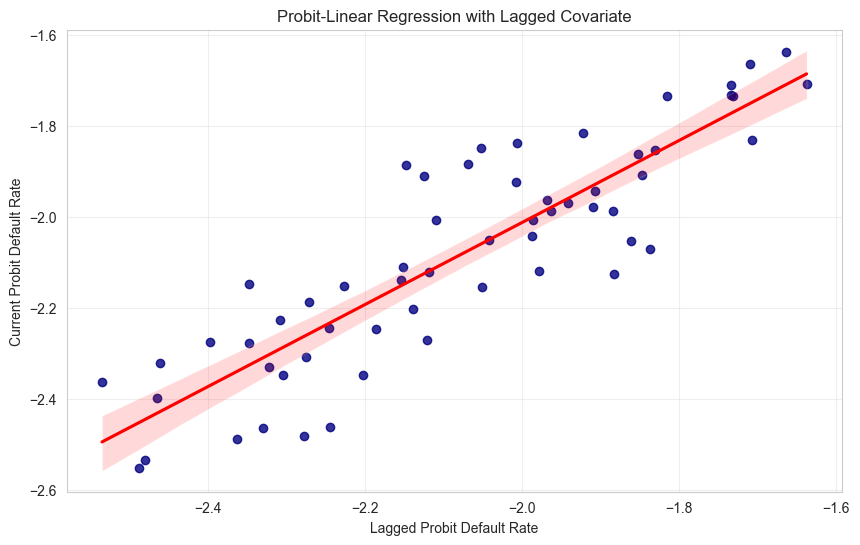

In [154]:
plt.figure(figsize=(10, 6))
sns.regplot(x='probit_lagged', y='Probit_dr', data=regression_data, 
            scatter_kws={'color': 'navy'}, line_kws={'color': 'red'})
plt.title('Probit-Linear Regression with Lagged Covariate')
plt.xlabel('Lagged Probit Default Rate')
plt.ylabel('Current Probit Default Rate')
plt.grid(True, alpha=0.3)
plt.show()

In [155]:
exhibit_summary = pd.DataFrame({
    'Parameter': ['a'],
    'Estimate': [results_with_cov.params['a']],
    'Std Error': [results_with_cov.bse['a']],
    't-Value': [results_with_cov.tvalues['a']],
    'P-Value': [results_with_cov.pvalues['a']]
})
print(exhibit_summary)

a = results_with_cov.params['a']
var_c = results_with_cov.mse_resid
rho_estimate = var_c / (1 + var_c)
pd_estimate = norm.cdf(a / np.sqrt(1 + var_c))
print(f"Asset Correlation (rho): {rho_estimate:.6f}")
print(f"Long-run PD:             {pd_estimate:.6f}")

  Parameter  Estimate  Std Error   t-Value   P-Value
0         a -0.207804   0.135617 -1.532283  0.130985
Asset Correlation (rho): 0.013306
Long-run PD:             0.418233


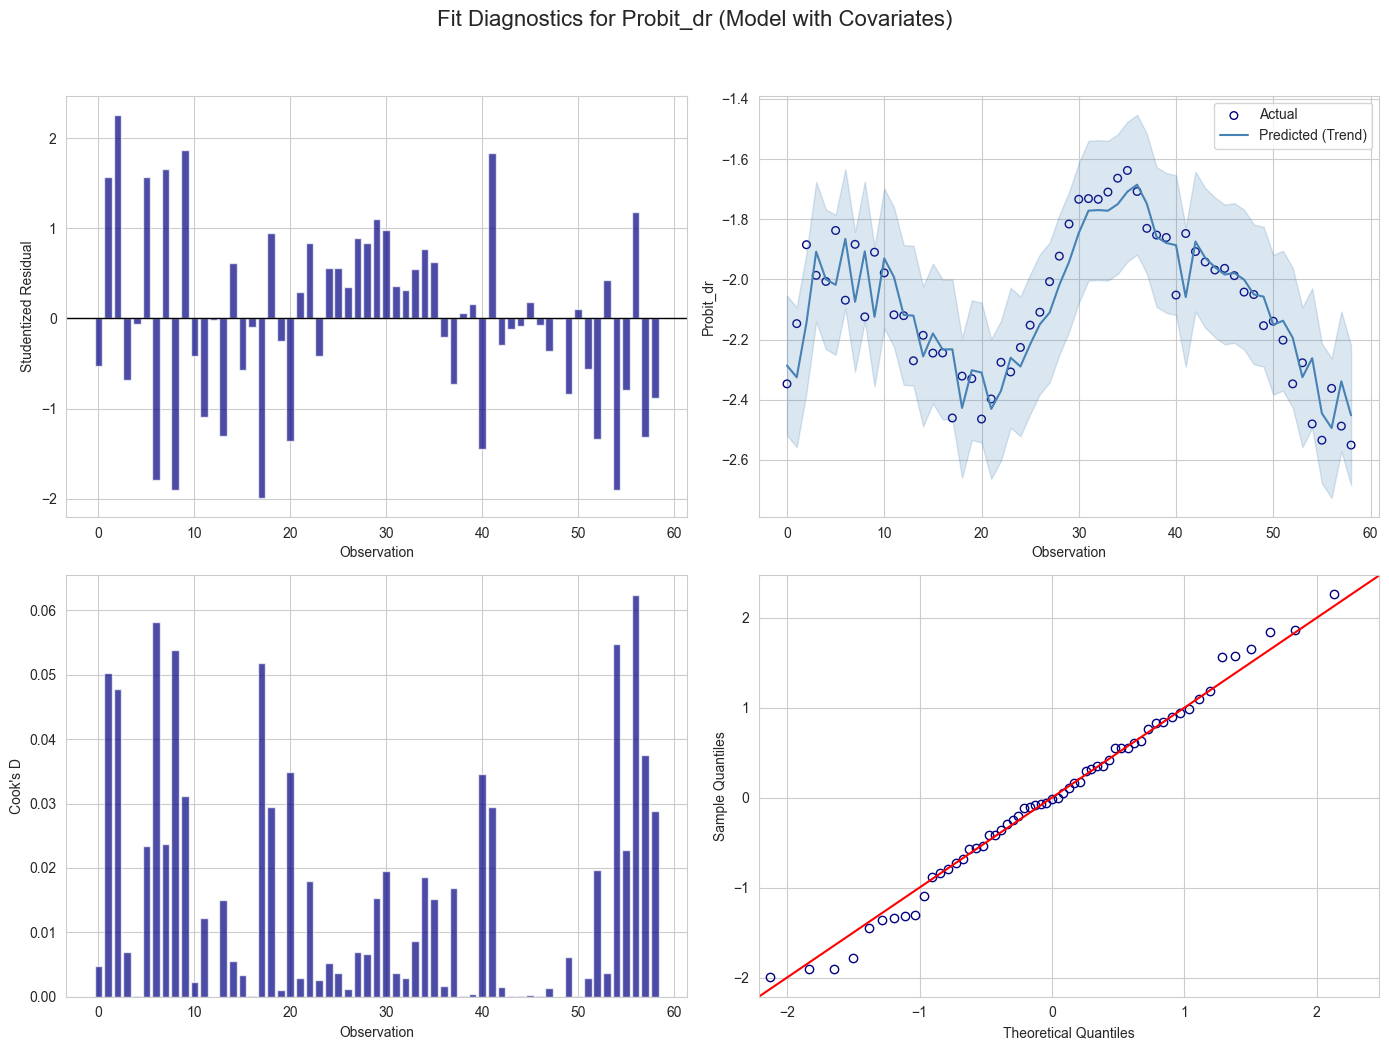

Observations: 59  MSE: 0.013485  Model DF: 1


In [156]:
influence = OLSInfluence(results_with_cov)
studentized_residuals = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
observations = np.arange(len(y))
fitted_values = results_with_cov.fittedvalues
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Fit Diagnostics for Probit_dr (Model with Covariates)', fontsize=16)
axes[0, 0].bar(observations, studentized_residuals, color='navy', alpha=0.7)
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_ylabel('Studentized Residual')
axes[0, 0].set_xlabel('Observation')
axes[0, 1].scatter(observations, y, facecolors='none', edgecolors='navy', s=30, label='Actual')
axes[0, 1].plot(observations, fitted_values, color='steelblue', label='Predicted (Trend)')


std_err = np.sqrt(results_with_cov.mse_resid)
axes[0, 1].fill_between(observations, fitted_values - 2*std_err, 
                         fitted_values + 2*std_err, color='steelblue', alpha=0.2)
axes[0, 1].set_ylabel('Probit_dr')
axes[0, 1].set_xlabel('Observation')
axes[0, 1].legend()

# --- Bottom Left: Cook's D ---
axes[1, 0].bar(observations, cooks_d, color='navy', alpha=0.7)
axes[1, 0].set_ylabel("Cook's D")
axes[1, 0].set_xlabel('Observation')

# --- Bottom Right: Q-Q Plot ---
# Use the standardized residuals from the influence object
std_resid = influence.resid_studentized_internal

# Plot these against the 45-degree line
sm.qqplot(std_resid, line='45', ax=axes[1, 1], markerfacecolor='none', markeredgecolor='navy')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Observations: {len(y)}  MSE: {results_with_cov.mse_resid:.6f}  Model DF: {int(results_with_cov.df_model)}")

Now let's try it with gdp.

In [157]:
df_ar = tmp2.sort_values('time').copy()
y = df_ar['Probit_dr']
exog = df_ar[['gdp_time']]
model_ar = ARIMA(y, exog=exog, order=(3, 0, 0))
results_ar = model_ar.fit()
print(results_ar.summary())

                               SARIMAX Results                                
Dep. Variable:              Probit_dr   No. Observations:                   60
Model:                 ARIMA(3, 0, 0)   Log Likelihood                  50.202
Date:                Sat, 14 Mar 2026   AIC                            -88.404
Time:                        13:27:45   BIC                            -75.838
Sample:                             0   HQIC                           -83.489
                                 - 60                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1111      0.177    -11.933      0.000      -2.458      -1.764
gdp_time      -0.0378      0.018     -2.083      0.037      -0.073      -0.002
ar.L1          0.5469      0.142      3.840      0.0

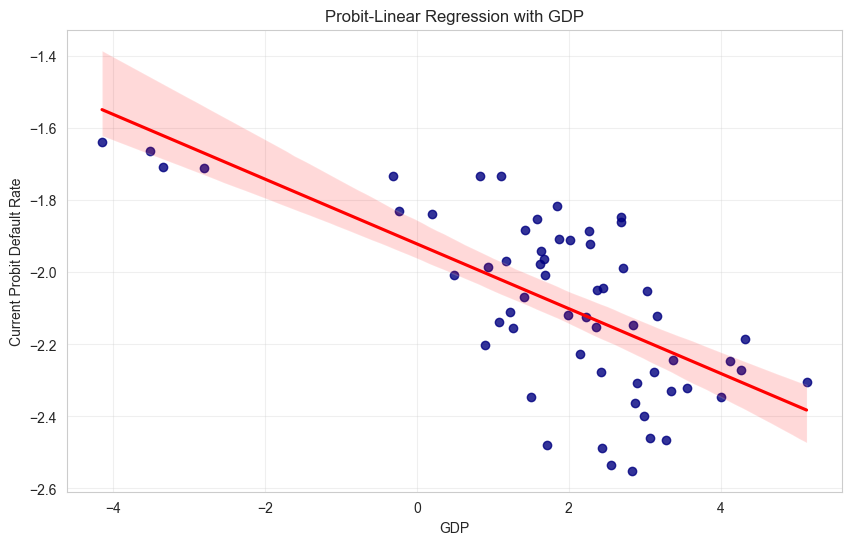

In [158]:
plt.figure(figsize=(10, 6))
sns.regplot(x='gdp_time', y='Probit_dr', data=df_ar, 
            scatter_kws={'color': 'navy'}, line_kws={'color': 'red'})
plt.title('Probit-Linear Regression with GDP')
plt.xlabel('GDP')
plt.ylabel('Current Probit Default Rate')
plt.grid(True, alpha=0.3)
plt.show()

In [159]:
exhibit_summary = pd.DataFrame({
    'Parameter': ['a'],
    'Estimate': [results_ar.params['const']],
    'Std Error': [results_ar.bse['const']],
    't-Value': [results_ar.tvalues['const']],
    'P-Value': [results_ar.pvalues['const']]
})
print(exhibit_summary)

a = results_ar.params['const']
var_c = results_ar.params['sigma2']
rho_estimate = var_c / (1 + var_c)
pd_estimate = norm.cdf(a / np.sqrt(1 + var_c))
print(f"Asset Correlation (rho): {rho_estimate:.6f}")
print(f"Long-run PD:             {pd_estimate:.6f}")

  Parameter  Estimate  Std Error    t-Value       P-Value
0         a -2.111101   0.176918 -11.932636  7.999976e-33
Asset Correlation (rho): 0.010570
Long-run PD:             0.017868


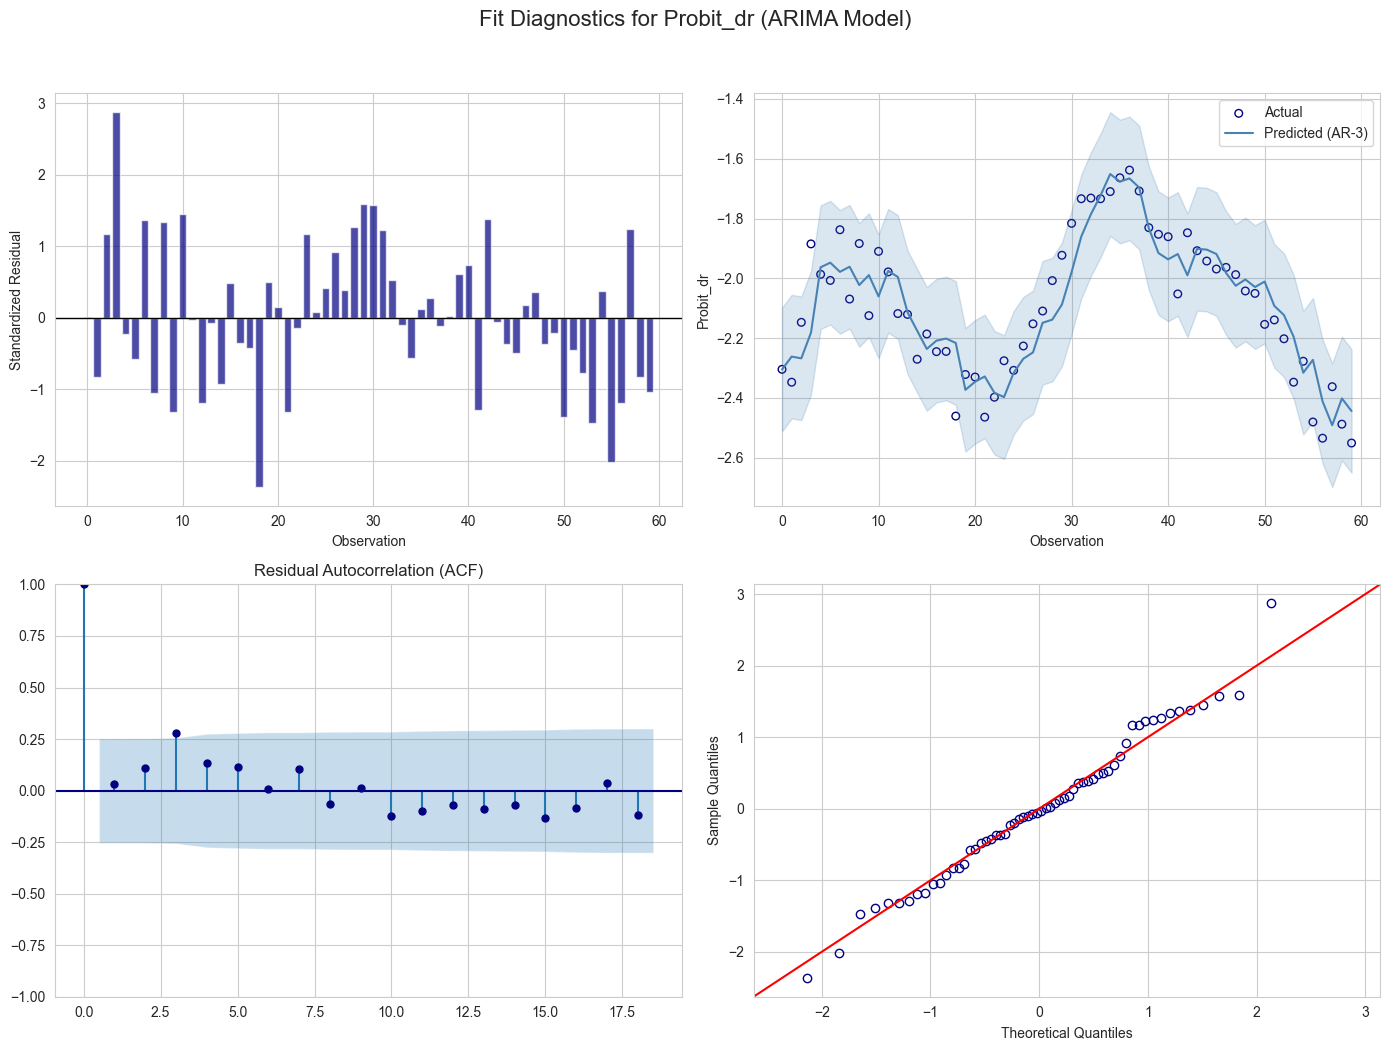

Observations: 60  Sigma2 (MSE): 0.010683


In [160]:
std_resid = results_ar.resid / np.sqrt(results_ar.params['sigma2'])
fitted_values = results_ar.fittedvalues
observations = np.arange(len(y))
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Fit Diagnostics for Probit_dr (ARIMA Model)', fontsize=16)

# --- Top Left: Standardized Residuals ---
axes[0, 0].bar(observations, std_resid, color='navy', alpha=0.7)
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_ylabel('Standardized Residual')
axes[0, 0].set_xlabel('Observation')

# --- Top Right: Predicted vs. Actual ---
axes[0, 1].scatter(observations, y, facecolors='none', edgecolors='navy', s=30, label='Actual')
axes[0, 1].plot(observations, fitted_values, color='steelblue', label='Predicted (AR-3)')
# Use sigma (sqrt of sigma2) for the confidence band
sigma = np.sqrt(results_ar.params['sigma2'])
axes[0, 1].fill_between(observations, fitted_values - 2*sigma, 
                         fitted_values + 2*sigma, color='steelblue', alpha=0.2)
axes[0, 1].set_ylabel('Probit_dr')
axes[0, 1].set_xlabel('Observation')
axes[0, 1].legend()

# --- Bottom Left: ACF (Autocorrelation Function) ---
# This replaces Cook's D for time-series validation
sm.graphics.tsa.plot_acf(results_ar.resid, ax=axes[1, 0], color='navy')
axes[1, 0].set_title("Residual Autocorrelation (ACF)")

# --- Bottom Right: Q-Q Plot ---
sm.qqplot(std_resid, line='45', ax=axes[1, 1], markerfacecolor='none', markeredgecolor='navy')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Observations: {len(y)}  Sigma2 (MSE): {results_ar.params['sigma2']:.6f}")

## Extensions

### model Specifications Other than Gaussian

The models in this chapter might seems rather restrictive at first sight because the basic framework introduced normally distributed variables while in risk management the assumption of a normal distribution is often not reasonable, as asset returns usually have fatter tails than the normal distribution and exhibit asymmetry. As in the book, we will show other options.

To compute the parameters for the non-Guassian models, we use a moments-matching approach, such that mean and variance of the distribution are the same. Given the PD and the asset correlation $\rho$ in the Gaussian model, the variance is obtained by $Var = \Phi_2(c,c,\rho) - PD^2$ where, as before, $c=\Phi^{-1}(PD)$ and $\Phi_2$ us the CDF of the bivariate normal distribution.

As CR+ use the gamma distribution, the parameters are obtained as $\alpha = \frac{PD^2}{Var}$ and $\beta = \frac{1}{\alpha}$. For the Clayton copula with dispersion parameter $\theta$, the variance is $Var_c = \phi^{-1}(2\phi(PD))-PD^2$, with $\phi(t) = t^{-\theta}-1$ and $\phi^{-1}(s) = (1+s)^{-\frac{1}{\theta}}$

In the CR+ and the Clayton model, the systematic factor is gamma distributed. Given the systematic factor, the conditional PD is computed and defaults are binomial or Poisson distributed.

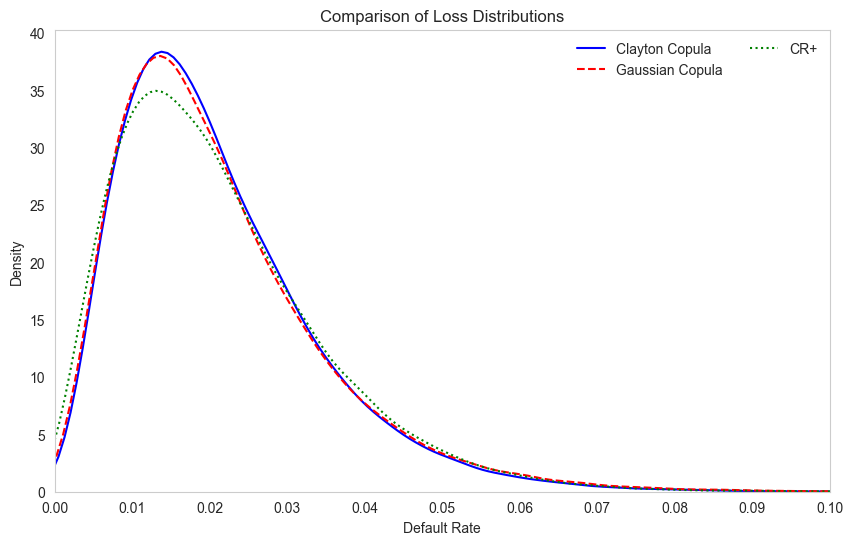

Percentiles of Default Rates:
       Clayton  Gaussian    CR+
50.0     0.018     0.018  0.019
95.0     0.046     0.047  0.047
99.0     0.063     0.066  0.063
99.5     0.070     0.074  0.070
99.9     0.086     0.093  0.088
100.0    0.144     0.166  0.134


In [161]:
# --- Set Global Parameters ---
Nsim = 100000
N = 1000

# --- Parameters for the Gaussian Model ---
pd_N = 0.0212
c = stats.norm.ppf(pd_N)
rho_N = 0.055
ksi_N = np.sqrt(1 - rho_N)

# Approximating Bivariate Normal for Var_CPD calculation
var_cpd = stats.multivariate_normal.cdf([c, c], mean=[0, 0], cov=[[1, rho_N], [rho_N, 1]]) - pd_N**2

# --- Parameters for the CR+ Model ---
pd_C = pd_N
alpha_C = (pd_C**2) / var_cpd
beta_C = 1 / alpha_C

# --- Parameters for the Clayton Copula Model ---
pd_T = pd_N
theta = 0.020401

# Gaussian Model
z_N = np.random.standard_normal(Nsim)
# Conditional PD calculation
cpd_N = stats.norm.cdf((stats.norm.ppf(pd_N) - np.sqrt(rho_N) * z_N) / ksi_N)
out_N = np.random.binomial(N, cpd_N) / N

# CR+ Model
z_C = beta_C * np.random.gamma(alpha_C, 1, Nsim)
cpd_C = N * pd_C * z_C
# Using Poisson distribution for defaults as per CR+
out_C = np.random.poisson(cpd_C) / N

# Clayton Copula Model
z_T = np.random.gamma(1/theta, 1, Nsim)
cpd_T = np.exp(-(pd_T**(-theta) - 1) * z_T)
out_T = np.random.binomial(N, cpd_T) / N

# --- Analysis and Plotting ---

def get_hist_data(data, bins):
    counts, bin_edges = np.histogram(data, bins=bins, density=False)
    # Convert to percentages like SAS _OBSPCT_
    pct = (counts / len(data)) * 100
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
    return midpoints, pct

bins = np.arange(0, 0.121, 0.001)
m_T, p_T = get_hist_data(out_T, bins)
m_N, p_N = get_hist_data(out_N, bins)
m_C, p_C = get_hist_data(out_C, bins)

plt.figure(figsize=(10, 6))

# Use KDE (Kernel Density Estimation) for smoothing
sns.kdeplot(out_T, label='Clayton Copula', color='blue', bw_adjust=1.5)
sns.kdeplot(out_N, label='Gaussian Copula', color='red', linestyle='--', bw_adjust=1.5)
sns.kdeplot(out_C, label='CR+', color='green', linestyle=':', bw_adjust=1.5)

# Formatting to match the Exhibit 9.16
plt.title('Comparison of Loss Distributions', fontsize=12)
plt.xlabel('Default Rate')
plt.ylabel('Density') # SAS uses Percent, but Density is standard for KDE
plt.xlim(0.00, 0.10)
plt.ylim(0, None)

# Add ticks similar to the SAS plot
plt.xticks(np.arange(0, 0.11, 0.01))

plt.legend(loc='upper right', frameon=False, ncol=2)
plt.grid(False) # The original SAS plot has a clean white background
plt.show()

# --- Display Percentiles (Equivalent to PROC UNIVARIATE OUTPUT) ---
models = {'Clayton': out_T, 'Gaussian': out_N, 'CR+': out_C}
percentiles = [50, 95, 99, 99.5, 99.9, 100]
summary = pd.DataFrame({k: np.percentile(v, percentiles) for k, v in models.items()}, index=percentiles)
print("Percentiles of Default Rates:")
print(summary)

The SAS code has given us the value for $\theta$, but, if needed it can be calbrated through its direct relationship with Kendall's Tau, if you know the correlation between your assets, you can find $\theta$ as:

$$\theta = \frac{2\tau}{1-\tau}$$

with $\tau = \frac{2}{\pi}\arcsin(\rho)$. It's just important to remember that using Guassian correlation ($\rho$), this form of obtaining $\tau$ is an approximation, as the copulas have different "shapes" (with Clayton having a heavy lower-tail dependence).

In [162]:
rho_N = 0.055
tau = (2 / np.pi) * np.arcsin(rho_N)
theta_calc = (2 * tau) / (1 - tau)

print(f"Calculated Theta: {theta_calc:.6f}")

Calculated Theta: 0.072607


Another option is a numerical calibration to match variance, that is, ensure the variance of the conditional probability of default is identical across models.

Since the Guassian variance is:

$$Var(CPD_{Guassian}) = \Phi_2(c,c,\rho)-PD^2$$

and the Clayton variance is a function of $\theta$ as given above, we can find theta numerically

In [163]:
import numpy as np
from scipy.stats import norm, multivariate_normal
from scipy.optimize import fsolve

# --- Inputs ---
pd_N = 0.0212
rho_N = 0.055
c = norm.ppf(pd_N)

var_target = multivariate_normal.cdf([c, c], mean=[0, 0], cov=[[1, rho_N], [rho_N, 1]]) - pd_N**2

# CPD_T = exp(-(PD_T**(-theta)-1) * Z_T) where Z_T ~ Gamma(1/theta, 1)
def sas_clayton_variance(theta, pd, target_var):
    if theta <= 0: return 1e6
    # Let K = pd**(-theta) - 1
    K = pd**(-theta) - 1
    # The expected value E[exp(-2*K*Z)] for Z ~ Gamma(a, 1) is (1 + 2*K)**(-a)
    # Here a = 1/theta
    term1 = (1 + 2 * K)**(-1/theta)
    actual_var = term1 - pd**2
    
    return actual_var - target_var

theta_solution = fsolve(sas_clayton_variance, x0=0.02, args=(pd_N, var_target))

print(f"Target Var: {var_target:.8f}")
print(f"Calibrated Theta: {theta_solution[0]:.6f}")

Target Var: 0.00015914
Calibrated Theta: 0.022141


### Models with Idiosyncratic Effects

The earlier models for estimating correlations used aggregated data (default rates). This is sufficient if the portfolio or segment is alrge and idiosyncratic risk is diversified. For smaller segments, the models can be extended to include idiosyncratic effects. Then we actually obtain a  nonlinear panel regression model with mixed effects. As the book won't go into details as these approeaches are quite advanced, we will not go into these topics in this notebook, but I'll leave the references the book has given for these:

- [Rösch and Scheule (2004)](https://www.researchgate.net/publication/29866029_Forecasting_Retail_Portfolio_Credit_Risk)
- [Rösch (2005)](https://ideas.repec.org/a/eee/intfor/v21y2005i1p37-51.html)
- [Hamerle and Rösch (2006)](https://www.risk.net/journal-credit-risk/2160579/parameterizing-credit-risk-models)

With the first being more focused on Retail and the other two on corporate.

### Models and Estimation Risk

Usually banjs have yearly data available for estimation, and time series are hardly longer than 20 or 30 years. Thus, we have only about 20 to 30 observations for estimating correlations, which imposes sparse data and nonstationarity issues, as correlations are estimated using the time-series dimension rather than the cross-section dimension of the data. Even if we assume stationarity and no structural breaks, the standard errors of the correlation estimates might be quite high and asset correlation estimates might be downward biased. The models that are presented here can be extended to deal with time-varying correlations and strucutral breaks, but again, are beyond this notebook that is following the book.